Entrenando con SGD...
Época 1 - Loss: 0.7498
Época 2 - Loss: 0.3669
Época 3 - Loss: 0.3210
Época 4 - Loss: 0.2938
Época 5 - Loss: 0.2732
Época 6 - Loss: 0.2538
Época 7 - Loss: 0.2367
Época 8 - Loss: 0.2213
Entrenando con Adam...
Época 1 - Loss: 0.3869
Época 2 - Loss: 0.2630
Época 3 - Loss: 0.2472
Época 4 - Loss: 0.2348
Época 5 - Loss: 0.2328
Época 6 - Loss: 0.2267
Época 7 - Loss: 0.2249
Época 8 - Loss: 0.2316


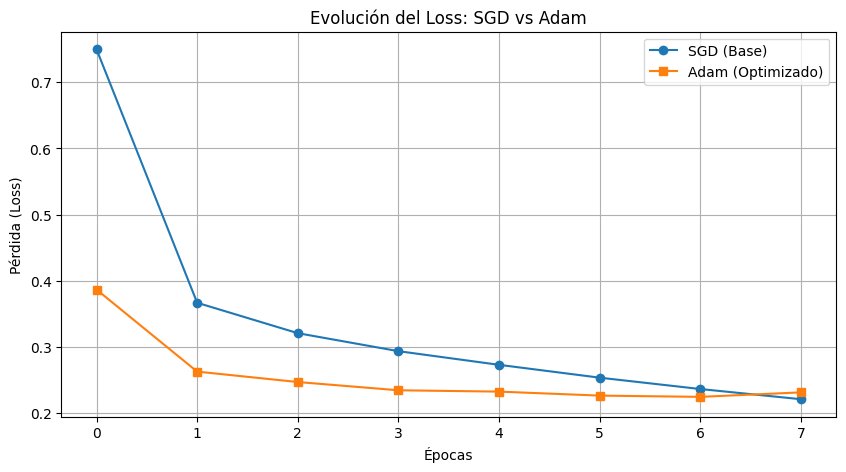


--- Resultados Finales de Precisión (Accuracy) ---
Precisión con SGD: 94.11%
Precisión con Adam: 94.30%


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# 1. FUNCIÓN DE REPRODUCIBILIDAD
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42) # Usar la misma semilla siempre

# 2. CONFIGURACIÓN Y DATOS
# Configuración base (constantes)
BATCH_SIZE = 64
EPOCHS = 8
LEARNING_RATE = 0.01

# Transformaciones y Carga de Datos
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

# 3. ARQUITECTURA DE LA RED (Modelo Base)
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.main(x)

  # Función auxiliar para evaluar precisión
def calculate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

#  Experimento 1: Optimización con SGD (Modelo Base)

set_seed(42) # Fijamos semilla antes de crear el cargador y el modelo
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

model_sgd = SimpleNet()
criterion = nn.CrossEntropyLoss()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=LEARNING_RATE)

history_sgd = []

print("Entrenando con SGD...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer_sgd.zero_grad()
        outputs = model_sgd(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_sgd.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    history_sgd.append(avg_loss)
    print(f"Época {epoch+1} - Loss: {avg_loss:.4f}")


# Experimento 2: Optimización con ADAM (Técnica Mejorada)
set_seed(42) # Fijamos semilla antes de crear el cargador y el modelo
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)


model_adam = SimpleNet()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=LEARNING_RATE)

history_adam = []

print("Entrenando con Adam...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer_adam.zero_grad()
        outputs = model_adam(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_adam.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    history_adam.append(avg_loss)
    print(f"Época {epoch+1} - Loss: {avg_loss:.4f}")

 # 4. COMPARACIÓN VISUAL y ANALISIS DE RESULTADOS

plt.figure(figsize=(10, 5))
plt.plot(history_sgd, label='SGD (Base)', marker='o')
plt.plot(history_adam, label='Adam (Optimizado)', marker='s')
plt.title('Evolución del Loss: SGD vs Adam')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True)
plt.show()

# 4.RESULTADOS FINALES (Precisión/Accuracy)

# Calcular para ambos
acc_sgd = calculate_accuracy(model_sgd, train_loader)
acc_adam = calculate_accuracy(model_adam, train_loader)

print(f"\n--- Resultados Finales de Precisión (Accuracy) ---")
print(f"Precisión con SGD: {acc_sgd:.2f}%")
print(f"Precisión con Adam: {acc_adam:.2f}%")

Análisis y Conclusiones

Tras ejecutar el entrenamiento y comparar las gráficas de SGD (Base) y frente a Adam (Optimizado), basadas en los resultados obtenidos.

1. Diferencias observadas entre configuraciones.

    La diferencia más notable entre ambas configuraciones fue la capacidad de respuesta inicial.

- Con la configuración de SGD, el modelo comenzó con una pérdida (Loss) muy alta de 0.7498, lo que indica que al principio le costo un poco identificar los patrones de los datos.

- Por el contrario, la configuración de Adam, el entrenamiento arrancó con unos Loss más bajos de 0.3869.

    Prácticamente, usando la misma tasa de aprendizaje (0.01) y el mismo número de épocas (8), Adam comienza el emtrenamiento en un punto de optimización que a SGD le toma casi tres épocas completas.

2. Estabilidad/velocidad de convergencia.

    Al observar la gráfica y los registros, la velocidad de convergencia de Adam es superior, aunque SGD muestra una mejora constante y muy estable.

- Velocidad:Adam es claramente superior en rapidez. Alcanzó un Loss de 0.2348 en apenas la Época 4, mientras que SGD necesitó llegar hasta la Época 7 (0.2367) para acercarse a ese nivel..

- Estabilidad:  Aquí hubo un resultado interesante. Mientras que SGD mostró un descenso constante y suave, Adam mostró una ligera inestabilidad al final en la Época 8, el Loss de Adam subió a 0.2316 ( cuando venía de 0.2249 en la Época 7). Esto sugiere que para este modelo, la tasa de aprendizaje de 0.01 podría ser un poco alta para Adam al final del entrenamiento, provocando pequeñas oscilaciones..

3. Principales hallazgos o dificultades.

- Eficiencia en ciclos cortos: Mi hallazgo es que si el tiempo de cómputo es limitado (pocas épocas), Adam es la opción más viable por su agresividad inicial.

- Dificultades de ajuste: La mayor dificultad observada es el "estancamiento" o rebote de Adam tras la Época 5. Mientras SGD sigue bajando de forma segura, Adam parece haber encontrado un límite con los hiperparámetros actuales

    Conclusión para este caso de estudio, Adam es preferible por su eficiencia inicial, aunque SGD demuestra ser más robusto y predecible a largo plazo, terminando incluso con un Loss ligeramente menor (0.2213) y más estable que el de Adam en este experimento.


